# Hawkes process (self-excitation)

A Hawkes process is a *self-exciting* arrival process: each event temporarily raises the probability of further events, producing the clustered bursts seen in trades, earthquakes, and social-media cascades. It is the natural counterpoint to the memoryless Poisson process.

::: {.callout-note}
## The model

The arrival intensity is a baseline rate plus a decaying kick after every event, so activity begets activity. The excitation strength and decay set how tightly events cluster and how long a burst lasts; below a stability threshold the process stays finite.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import HawkesProcessGenerator

## 1. Event counts (default output)

Generate event count time series with a baseline intensity and self-excitation.

In [ ]:
params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "h",
    "baseline_intensity": 1.0,
    "excitation_amplitude": 0.5,
    "decay_rate": 2.0,
    "output_type": "counts",
    "seed": 42,
}

generator = HawkesProcessGenerator(engine="polars", **params)
df = generator.generate(n_series=3)

print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total observations: {len(df)}")
print(f"Total events: {df['y'].sum()}")

stats = df.group_by("unique_id").agg(
    [
        pl.col("y").sum().alias("total_events"),
        pl.col("y").mean().alias("mean_per_hour"),
        pl.col("y").max().alias("max_in_hour"),
    ]
)
stats

Generated 3 time series
Total observations: 600
Total events: 836.0


unique_id,total_events,mean_per_hour,max_in_hour
cat,f64,f64,f64
"""1""",305.0,1.525,7.0
"""2""",245.0,1.225,7.0
"""0""",286.0,1.43,6.0


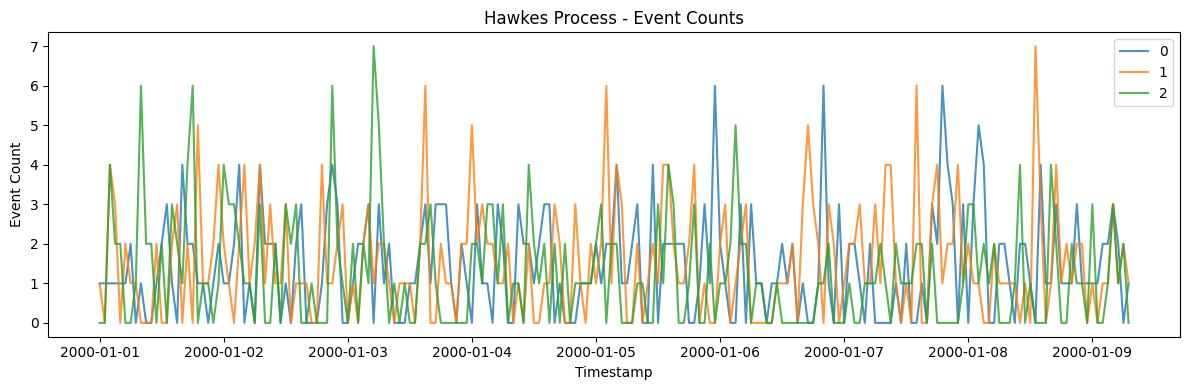

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("Hawkes Process - Event Counts")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Intensity process

Output the underlying intensity function instead of event counts.

In [ ]:
intensity_gen = HawkesProcessGenerator(engine="polars", 
    **{
        "min_length": 100,
        "max_length": 100,
        "freq": "h",
        "baseline_intensity": 0.5,
        "excitation_amplitude": 0.3,
        "decay_rate": 1.0,
        "output_type": "intensity",
        "seed": 42,
    }
)
intensity_df = intensity_gen.generate(n_series=1)

print(f"Intensity range: [{intensity_df['y'].min():.3f}, {intensity_df['y'].max():.3f}]")
print(f"Mean intensity: {intensity_df['y'].mean():.3f}")

Intensity range: [0.501, 1.510]
Mean intensity: 0.723


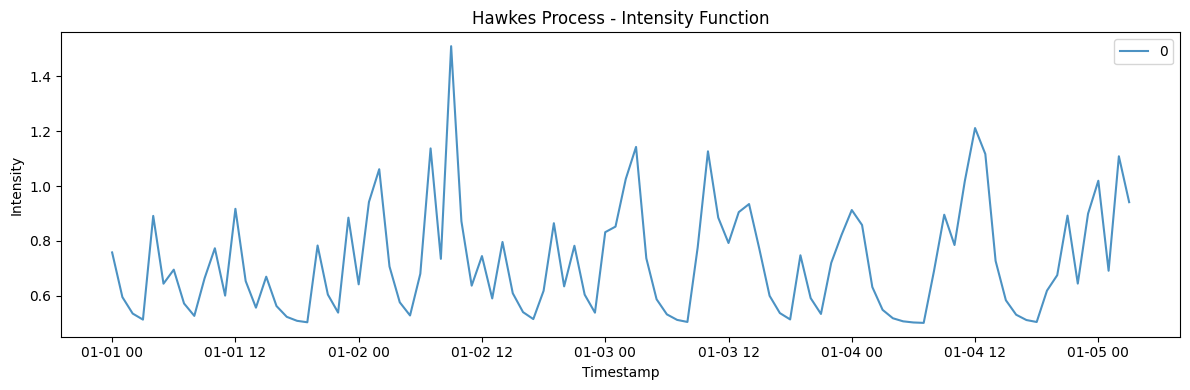

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in intensity_df["unique_id"].unique().to_list():
    series = intensity_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Intensity")
ax.set_title("Hawkes Process - Intensity Function")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Model information and stability

Inspect model parameters including the branching ratio which determines stability.

In [ ]:
info = generator.get_model_info()
print(f"Baseline intensity (mu): {info['baseline_intensity']}")
print(f"Excitation amplitude (alpha): {info['excitation_amplitude']}")
print(f"Decay rate (beta): {info['decay_rate']}")
print(f"Branching ratio (alpha/beta): {info['branching_ratio']:.3f}")
print(f"Expected cluster size: {info['expected_cluster_size']:.3f}")
print(f"Process is stable: {info['is_stable']}")

Baseline intensity (mu): 1.0
Excitation amplitude (alpha): 0.5
Decay rate (beta): 2.0
Branching ratio (alpha/beta): 0.250
Expected cluster size: 1.333
Process is stable: True


## 4. Raw event simulation

Directly simulate event arrival times and their associated intensities.

In [ ]:
event_times, intensities = generator.simulate_with_events(time_horizon=50.0)
print(f"Simulated {len(event_times)} events over 50 time units")
print(f"Event rate: {len(event_times) / 50:.2f} events/unit time")
print(f"First 10 event times: {event_times[:10].round(3)}")

Simulated 64 events over 50 time units
Event rate: 1.28 events/unit time
First 10 event times: [1.714 2.527 2.584 3.022 3.662 5.29  5.583 5.682 6.25  6.494]


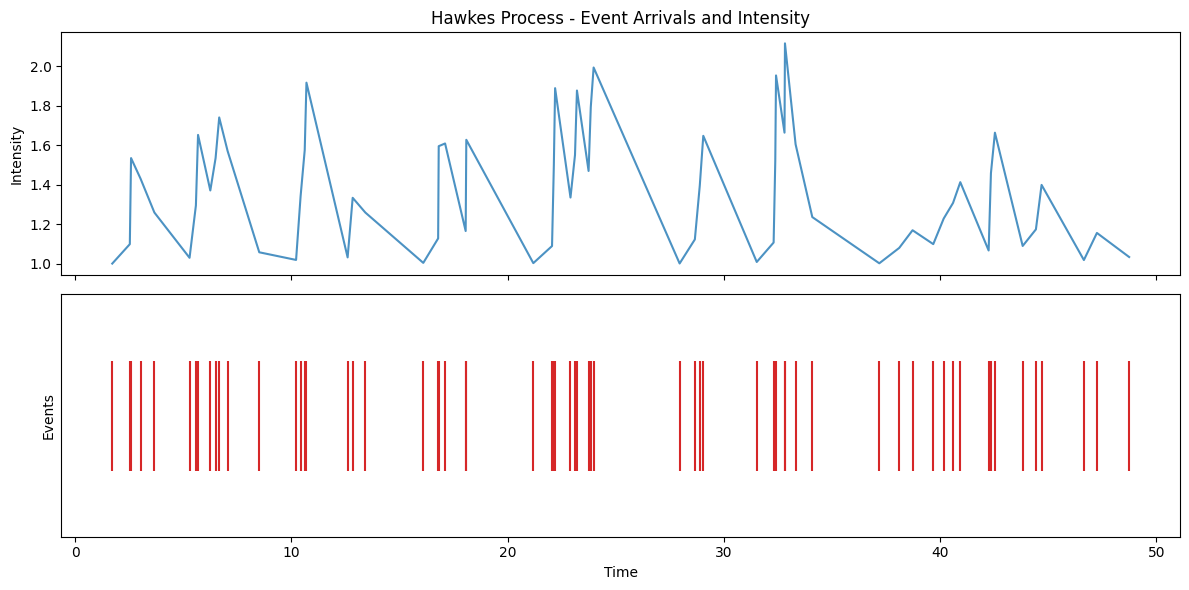

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(event_times, intensities, alpha=0.8)
axes[0].set_ylabel("Intensity")
axes[0].set_title("Hawkes Process - Event Arrivals and Intensity")
axes[1].eventplot([event_times], lineoffsets=0.5, linelengths=0.8, colors="tab:red")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Events")
axes[1].set_yticks([])
plt.tight_layout()
plt.show()

## 5. Power-law kernel

Use a power-law decay kernel instead of the default exponential kernel for longer memory effects.

In [ ]:
power_law_gen = HawkesProcessGenerator(engine="polars", 
    **{
        "min_length": 100,
        "max_length": 100,
        "freq": "h",
        "kernel": "power_law",
        "power_law_exponent": 1.5,
        "baseline_intensity": 0.5,
        "excitation_amplitude": 0.2,
        "seed": 42,
    }
)
power_law_df = power_law_gen.generate(n_series=1)
print(f"Power-law kernel total events: {power_law_df['y'].sum()}")

Power-law kernel total events: 76.0


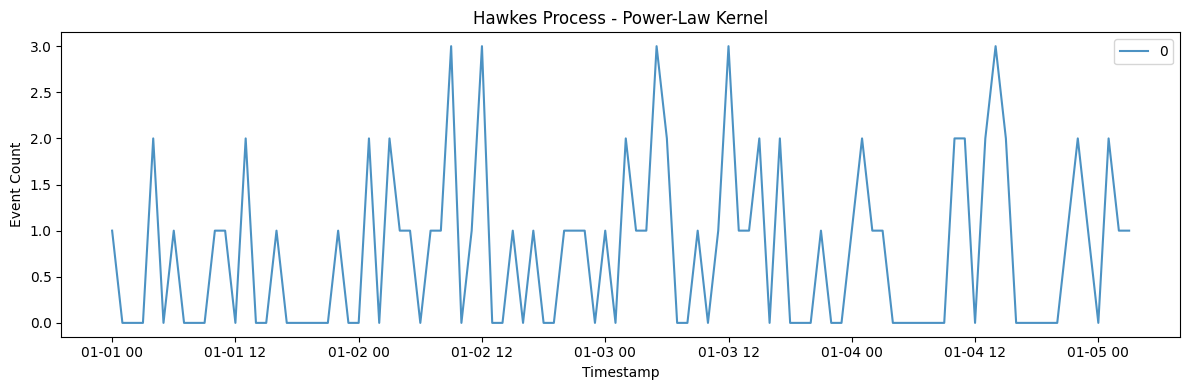

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in power_law_df["unique_id"].unique().to_list():
    series = power_law_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("Hawkes Process - Power-Law Kernel")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Poisson process](poisson_process) — the no-excitation baseline.
- [Jump diffusion](jump_diffusion) — continuous dynamics with discrete shocks.

Excitation and decay parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::